## __Partie 3 – Comparaison entre modèles et données réelles__

Cette partie vise à comparer nos modèles théoriques et simulations numériques à des données réelles issues d'un système proie-prédateur, afin d'évaluer leur pertinence.

### __3.1 Présentation des données réelles__

Avant de comparer nos modèles à la réalité, nous présentons ici les données historiques utilisées. Elles proviennent des enregistrements de la Hudson’s Bay Company entre 1845 et 1935, recensant chaque année les populations estimées de lièvres d’Amérique et de lynx du Canada, sur la base des chiffres de piégeage. Ces chiffres ne correspondent donc pas à la population totale, mais à une partie seulement : les individus effectivement piégés. On considère toutefois que ces données donnent une estimation indirecte de l’abondance réelle de chaque espèce, car plus une population est nombreuse, plus le nombre de captures tend à augmenter. Les lynx des neiges, se nourrissant de 60% à 97% de lièvres, sont considérés comme les prédateurs principaux de ces derniers. Ceci est donc pertinent pour notre étude, puisque nous modélisons uniquement des interactions entre deux espèces.

Ces données constituent un cas d’étude classique en écologie, particulièrement pertinent pour l'analyse des dynamiques proie-prédateur. De plus, elles couvrent une période suffisamment longue (près d’un siècle) pour observer plusieurs cycles naturels.

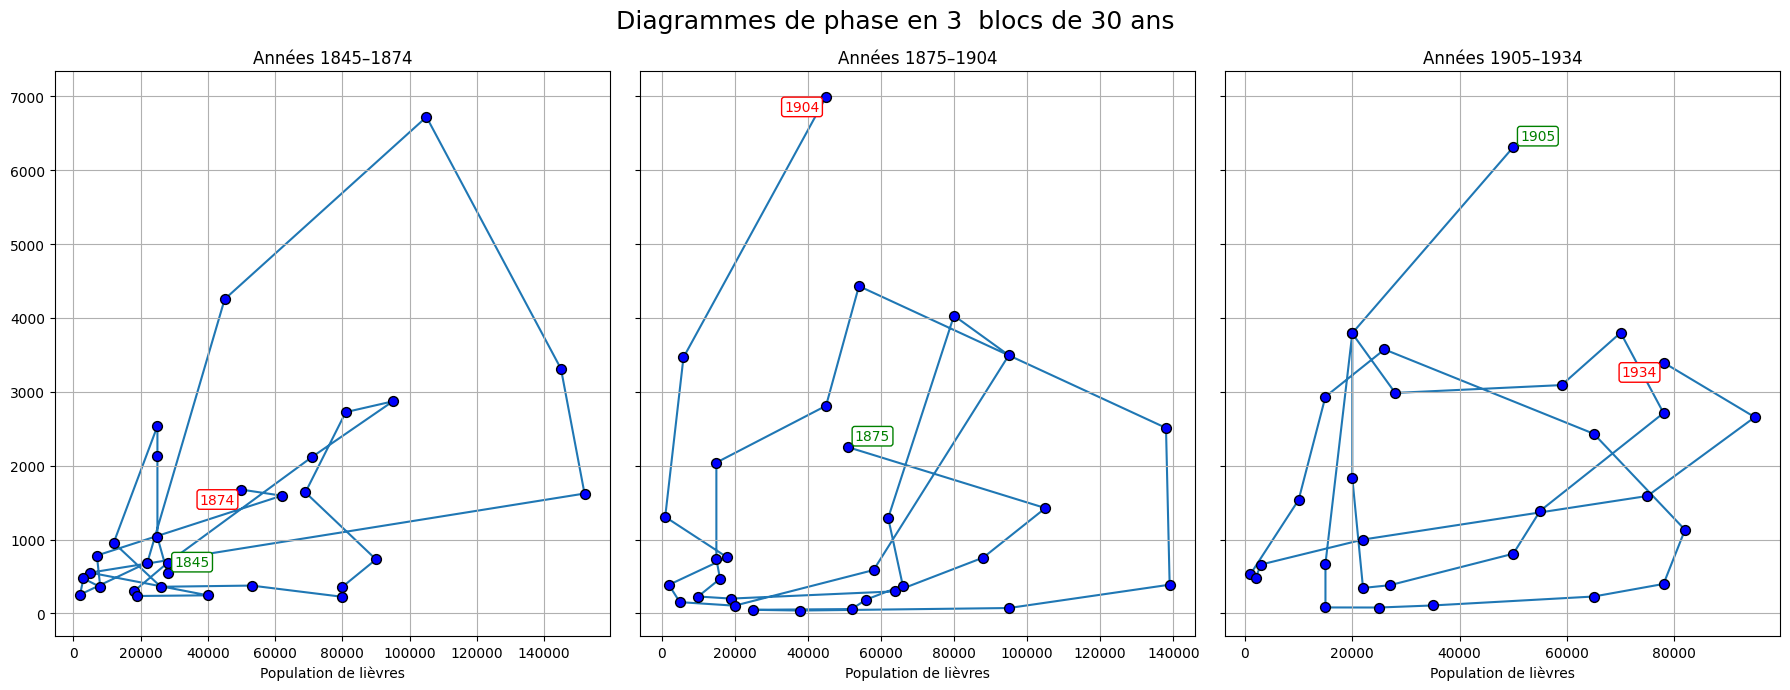

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

hare_df = pd.read_csv("lynxhare.csv", sep=';')
hare_df['year'] = pd.to_numeric(hare_df['year'], errors='coerce')
hare_df['hare'] = pd.to_numeric(hare_df['hare'], errors='coerce')
hare_clean = hare_df[['year', 'hare']].dropna()

# data avec les populations de lynx pour compléter l'autre data
df_lynx = pd.read_csv("lynx.csv", sep =',')
lynx_clean = df_lynx[['time', 'lynx']].rename(columns={'time': 'year'})

#on ne garde que les années communes entre les deux dataframes
merged_df = pd.merge(hare_clean, lynx_clean, on='year', how='inner')

# affichage des données par blocs de 30 ans
block_size = 30
n_blocks = 3

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
axes = axes.flatten()

for i in range(n_blocks):
    start = i * block_size
    end = start + block_size
    block = merged_df.iloc[start:end]
    
    x = block['hare'].values
    y = block['lynx'].values
    years = block['year'].values
    
    ax = axes[i]
    ax.plot(x, y, marker='o', zorder=1)
    
    ax.annotate(f"{years[0]}",
                xy=(x[0], y[0]), xytext=(5, 5),
                textcoords='offset points',
                fontsize=10, color='green',
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="green"), zorder=10)
    
    ax.annotate(f"{years[-1]}",
                xy=(x[-1], y[-1]), xytext=(-30, -10),
                textcoords='offset points',
                fontsize=10, color='red',
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="red"), zorder=10)
    ax.scatter(x, y, s=50, color='blue', edgecolor='k', zorder=3)
    ax.set_title(f"Années {years[0]}–{years[-1]}")
    ax.set_xlabel("Population de lièvres")
    ax.grid(True)

fig.suptitle("Diagrammes de phase en 3  blocs de 30 ans", fontsize=18)
plt.tight_layout()
plt.show()

On aperçoit que le diagramme de phase n'est pas stable et qu'on observe pas de fluctuation périodique identique chaque 30 ans. En effet, nous remarquons beaucoup de fluctuations statistiques. Cela peut être dû à la manière dont les données ont été collectées et à des facteurs externes comme un événement climatique, une maladie, etc. De plus, a priori, aucun équilibre stable n'est atteint (il faudrait beaucoup plus d'années pour voir si un équilibre émerge).


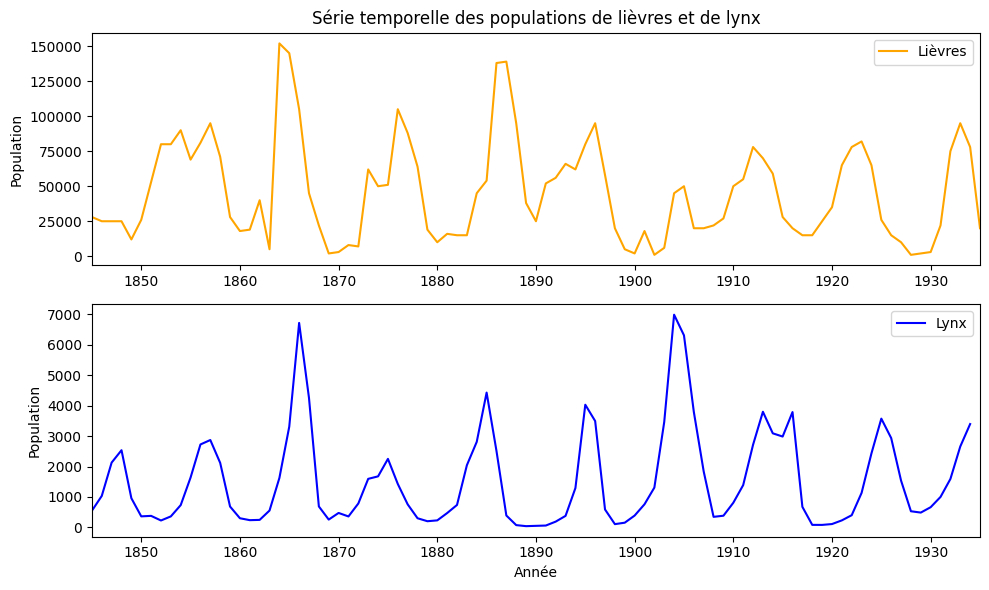

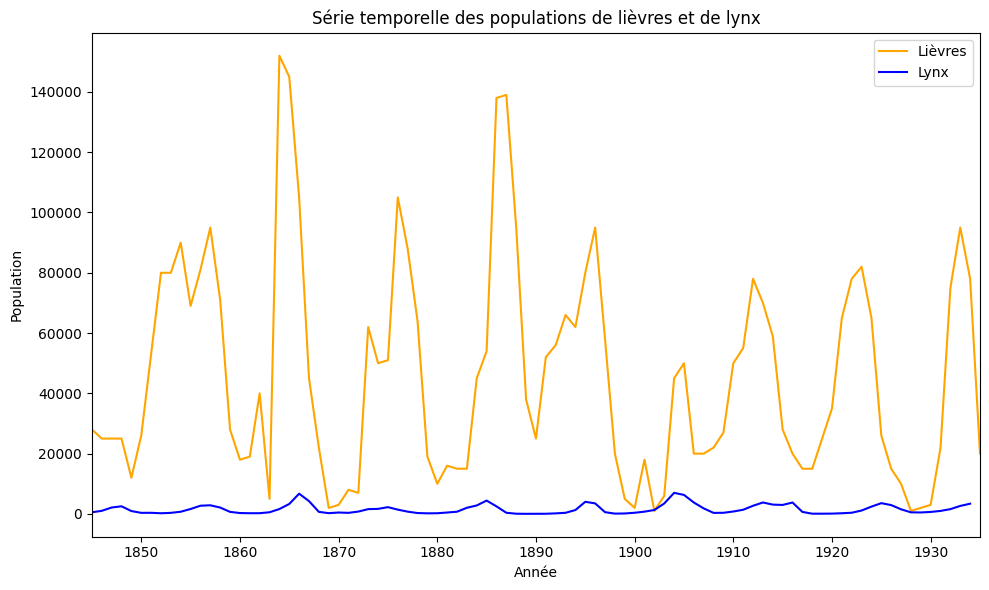

In [3]:
# Tracé de la série temporelle
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(hare_clean['year'], hare_clean['hare'], label='Lièvres', color='orange')
plt.ylabel('Population')
plt.xlim(1845, 1935)
plt.title('Série temporelle des populations de lièvres et de lynx')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(lynx_clean['year'], lynx_clean['lynx'], label='Lynx', color='blue')
plt.xlabel('Année')
plt.ylabel('Population')
plt.xlim(1845, 1935)
plt.legend()
plt.tight_layout()
plt.show()

# Tracé de la série temporelle avec les deux populations
plt.figure(figsize=(10, 6))
plt.plot(hare_clean['year'], hare_clean['hare'], label='Lièvres', color='orange')
plt.plot(lynx_clean['year'], lynx_clean['lynx'], label='Lynx', color='blue')
plt.xlabel('Année')
plt.ylabel('Population')
plt.title('Série temporelle des populations de lièvres et de lynx')
plt.xlim(1845, 1935)
plt.legend()
plt.tight_layout()
plt.show()


On remarque que les évolutions des populations au cours du temps oscillent entre des pics et des creux. On observe que lorsque la population de lièvres augmente, la population de lynx augmente également (mais avec un certain décalage temporel).
On peut noter que la population de lièvres est presque tout le temps environ dix fois plus élevée que celle des lynx et fluctue beaucoup plus.

Ces observations fourniront une base de comparaison pour nos modèles théoriques et simulations, abordés dans les sections suivantes.

### __3.2 Comparaison entre les données réelles et le modèle de Lotka-Volterra__

Pour cette comparaison, nous utilisons la version du modèle de Lotka-Volterra avec une capacité de charge sur les proies. En effet, dans un environnement naturel, les ressources sont limitées, ce qui empêche une croissance indéfinie de la population des proies.
Sur certains graphes de phase, plus particulièrement le deuxième, on remarque qu'il y a une allure cyclique, mais pas de manière régulière, ce qui est donc d'un côté différent de la dynamique prédite par le modèle de Lotka-Volterra. Comme nous l'avons remarqué, aucun équilibre stable n'est atteint, ce qui est aussi différent du modèle de Lotka-Volterra.
D'un autre côté, le modèle classique de Lotka-Volterra (sans la croissance logistique) arrive bien à retranscrire l'allure principale de la dynamique des populations observée, ce qui est déjà un bon point.


### __3.3 Comparaison entre les données réelles et la simulation__
Parmi les différentes simulations que nous avons réalisées, la simulation 5 est la plus pertinente pour la confrontation aux observations historiques. Nous la retenons pour trois raisons principales :

Nous observons beaucoup de fluctuations irrégulières dans les populations. Les pics des courbes ne sont ni strictement périodiques ni parfaitement symétriques, à l’image des données réelles. 

Tout au long de la simulation, la population des proies reste, en moyenne, un ordre de grandeur au-dessus de celle des prédateurs. Bien que la population des proies soit supérieure d'un facteur 2.5 à celle des prédateurs et non d'un facteur 10 (comme dans les données réelles), la simulation 5 reste la plus proche de la réalité. Cela peut être dû à la taille de la grille de simulation, qui est peut-être trop petite pour observer un facteur 10. 

On observe le même décalage temporel proies → prédateurs (hausse des lièvres avant celle des lynx) que dans les données. Aucun point d'équilibre stable n’émerge, ce qui reste cohérent avec les séries historiques observées.

Essayons d'interpréter les résultats de la simulation 5 par le choix de paramètres que nous avons faits. La simulation 5 se distingue des autres parce que les prédateurs y sont à la fois éphémères (mort de faim réduite à 8 pas) et moins résilients (reproduction modérée : 0,25), tandis que leur efficacité de chasse reste élevée (0,50). Dès qu’un petit creux de proies survient, la population de prédateurs s’effondre rapidement ; elle met ensuite du temps à se reconstituer, laissant aux proies, dont la reproduction est seulement moyenne (0,40), le champ libre pour augmenter de façon irrégulière.

### __3.4 Comparaison entre la simulation et le modèle de Lotka-Volterra__
Parmi les différentes simulations que nous avons réalisées, la simulation 2 est la plus pertinente pour la confrontation au modèle de Lotka-Volterra. Nous la retenons pour trois raisons principales :

Les oscillations sont plus régulières que par rapport aux autres simulations et rappellent les oscillations du modèle de Lotka-Volterra. De plus, le début du graphique rappelle fortement le début de ce que prédit le modèle.

Dans le diagramme de phase, la trajectoire décrit une spirale antihoraire qui se resserre progressivement ; elle n'atteint pas exactement un point fixe, mais tend vers une zone centrale. On peut dire que ce qu'on observe correspond à un mix des deux modèles de Lotka-Volterra qu'on a présenté : les populations oscillent autour d'un point d'équilibre (comme le montre les équations classiques), mais elles se resserent de plus en plus au cours du temps (rapellant donc le cas avec la capacité de charge).

On observe également que les nombres de populations des proies et des prédateurs se croisent sur le graphique temporelle, bien que le nombre de prédateurs soit toujours inférieur à celui des proies (ce qui figure aussi dans le modèle de Lotka-Volterra).

Essayons à nouveau d'interpréter les résultats de la simulation 2 par le choix de paramètres que nous avons fait. Dans cette simulation, nous obtenons des cycles plus réguliers parce que les paramètres sont précisément les plus « durs » de tous nos essais : les prédateur vivent plus longtemps ce qui impose une très grande contrainte sur la simulation en revanche les proies n’ont qu’une reproduction modérée (0,30) ; les prédateurs, eux, chassent peu (0,20), se reproduisent au même rythme (0,20) mais ces taux faibles ne compensent pas la contrainte de durée de vie des prédateurs.

### __3.5 Discussion finale__

Revenons à la question initiale : Comment peut-on modéliser fidèlement les dynamiques réelles des populations proies-prédateurs observées dans la nature ? La réponse est nuancée.

Le modèle de Lotka-Volterra permet effectivement de capturer l'allure générale des dynamiques proie-prédateur observées dans la nature, notamment les cycles de croissance et de décroissance des populations, ainsi que la tendance à atteindre un certain équilibre dynamique lorsque des capacités de charge sont introduites.  

 Cependant, ce modèle reste une simplification importante : il est déterministe et suppose des interactions moyennées et constantes entre les populations, ce qui limite son réalisme. Contrairement à notre simulation, qui considère explicitement les interactions individuelles et introduit donc une variabilité intrinsèque à chaque exécution, le modèle déterministe de Lotka-Volterra ne peut rendre compte de ces fluctuations aléatoires ou imprévues observées dans la nature. Ainsi, même si ce modèle constitue un bon outil pour comprendre les principes généraux des dynamiques de population, il reste trop simplifié pour capturer toutes les nuances des systèmes écologiques réels.  

Toutefois, notre simulation, qui est plus complexe, ne peut pas non plus être considérée comme un modèle parfait. En effet, nous n'avons pas pris en compte d'autres facteurs importants, comme les variations climatiques, les maladies, la compétition entre espèces... Peut-être qu'en ajoutant ces facteurs, nous pourrions obtenir un modèle encore plus proche de la réalité.

## __Conclusion__

Dans cette étude, nous avons exploré les dynamiques proie-prédateur à travers deux approches : le modèle classique de Lotka-Volterra et une simulation numérique basée sur un modèle agent. Nous avons constaté que le modèle de Lotka-Volterra, bien qu'il soit un bon point de départ pour comprendre les interactions entre espèces, présente des limitations en termes de réalisme et de prévision des dynamiques naturelles. En revanche, notre simulation permet de mettre en valeur les variations intrinsèques des systèmes écologiques, mais elle reste également simplifiée et ne prend pas en compte tous les facteurs influençant les populations.  

Pour aller plus loin, on pourrait imaginer ajouter d’autres espèces ou niveaux d’interaction dans les deux modèles. Par exemple, dans le modèle de Lotka-Volterra, on pourrait introduire une deuxième espèce de proie ou un superprédateur. Dans la simulation, on pourrait aussi intégrer une ressource pour les proies, comme de la végétation, qui pousserait et serait consommée. Cela permettrait d’observer des dynamiques encore plus proches des écosystèmes naturels.

## __Bibliographie__

###  __Références__

- de la Tousche, M. (2022). *Autour des équations de Lotka-Volterra et quelques apparentées en biologie : EDO, EDP, simulations*. Sorbonne Université. Disponible à l'adresse : [Autour des équations de Lotka-Volterra et quelques apparentées en biologie : EDO, EDP, simulations](https://who.rocq.inria.fr/Jean.Clairambault/Equations%20de%20Lotka%20Volterra%20et%20quelques%20apparentees.pdf)

  > Utilisé comme source pour les équations simples de Lotka-Volterra et pour le modèle de croissance logistique.

- [Wikipédia](https://fr.wikipedia.org/wiki/%C3%89quations_de_pr%C3%A9dation_de_Lotka-Volterra) 

  > Utilisé pour comprendre l'impact des paramètres sur les équations de Lotka-Volterra et choisir les valeurs des paramètres.


### __Données utilisées__

- Nous avons utilisé les données historiques de la Compagnie de la Baie d’Hudson, couvrant la période de 1845 à 1935, qui enregistrent le nombre annuel de peaux de lynx et de lièvre des neiges acquises auprès des trappeurs. Ces données, disponibles sur GitHub, ont été utilisées pour tracer les cycles prédateur-proie réels et comparer les résultats avec le modèle de Lotka-Volterra et la simulation numérique.

    > Source : [github](https://github.com/bblais/Systems-Modeling-Spring-2015-Notebooks/tree/master/data/Lynx%20and%20Hare%20Data)
